<a id="1"></a>
<div style="text-align: center; background: #1ED760; font-family: 'Trebuchet MS', Arial, sans-serif; color: white; padding: 15px; font-size: 26px; font-weight: bold; line-height: 1; border-radius: 50% 0 50% 0 / 40px; margin-bottom: 20px; box-shadow: 0px 4px 6px rgba(0, 0, 0, 0.1);">1. Import Libraries</div>


In [25]:
!pip install albumentations

In [26]:
import os
import numpy as np
import cv2
from glob import glob
from tqdm import tqdm

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import keras as k
from tensorflow.keras.models import load_model
from albumentations import HorizontalFlip, VerticalFlip, Rotate

import warnings
warnings.filterwarnings('ignore')
os.environ['TF_CUDNN_USE_AUTOTUNE'] = '0'

<a id="1"></a>
<div style="text-align: center; background: #1ED760; font-family: 'Trebuchet MS', Arial, sans-serif; color: white; padding: 15px; font-size: 26px; font-weight: bold; line-height: 1; border-radius: 50% 0 50% 0 / 40px; margin-bottom: 20px; box-shadow: 0px 4px 6px rgba(0, 0, 0, 0.1);">2. Load Data</div>


In [27]:
DATA_PATH = '/kaggle/input/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT'
CLASS = ['benign', 'malignant']
IMAGE_SIZE = (256, 256)

In [28]:
images = []
masks = []
imagesNames = []
masksNames  = []
for class_name in tqdm(CLASS):
    folder_path = os.path.join(DATA_PATH, class_name)
    imagesPaths = sorted(os.listdir(folder_path))
    for img in imagesPaths:
        imgPath = os.path.join(folder_path, img)
        if '_mask' not in img:
            imagesNames.append(imgPath)
            image = cv2.imread(imgPath)
            image = cv2.resize(image, IMAGE_SIZE)
            image = image / 255.0
            images.append(image)
        elif img.split('.')[-2][-1] == 'k':
            masksNames.append(imgPath)
            image = cv2.imread(imgPath, cv2.IMREAD_GRAYSCALE)
            image = cv2.resize(image, IMAGE_SIZE)
            image = image / 255.0
            masks.append(np.expand_dims(image, axis = -1))
    

100%|██████████| 2/2 [00:08<00:00,  4.48s/it]


In [29]:
masks[0].shape

(256, 256, 1)

In [30]:
# Check Orderd Imaged With Masks
for i in np.random.randint(0, len(images), size = 10):
    print('#' * 100)
    print(imagesNames[i])
    print(masksNames[i])

####################################################################################################
/kaggle/input/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/benign/benign (328).png
/kaggle/input/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/benign/benign (328)_mask.png
####################################################################################################
/kaggle/input/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/benign/benign (221).png
/kaggle/input/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/benign/benign (221)_mask.png
####################################################################################################
/kaggle/input/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/benign/benign (162).png
/kaggle/input/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/benign/benign (162)_mask.png
####################################################################################################
/kaggle/input/breast-ultrasou

<a id="1"></a>
<div style="text-align: center; background: #1ED760; font-family: 'Trebuchet MS', Arial, sans-serif; color: white; padding: 15px; font-size: 26px; font-weight: bold; line-height: 1; border-radius: 50% 0 50% 0 / 40px; margin-bottom: 20px; box-shadow: 0px 4px 6px rgba(0, 0, 0, 0.1);">3. Prepare Data</div>


In [31]:
images = np.array(images)
masks = np.array(masks)

In [32]:
train_images, X_test, train_masks, y_test = train_test_split(images, masks, shuffle = True, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(train_images, train_masks, shuffle = True, test_size=0.3, random_state=42)


print("Training images shape:", X_train.shape)
print("Validation images shape:", X_val.shape)
print("Test images shape:", X_test.shape)
print('-' * 50)
print("Training Mask shape:", y_train.shape)
print("Validation Mask shape:", y_val.shape)
print("Test Mask shape:", y_test.shape)

Training images shape: (361, 256, 256, 3)
Validation images shape: (156, 256, 256, 3)
Test images shape: (130, 256, 256, 3)
--------------------------------------------------
Training Mask shape: (361, 256, 256, 1)
Validation Mask shape: (156, 256, 256, 1)
Test Mask shape: (130, 256, 256, 1)


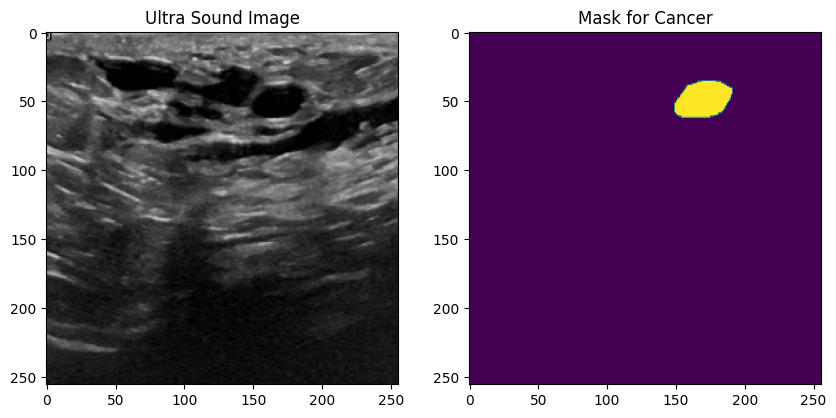

In [33]:
plt.figure(figsize = (10, 7))
plt.subplot(1,2,1)
plt.imshow(X_train[200])
plt.title('Ultra Sound Image')
plt.subplot(1,2,2)
plt.imshow(y_train[200])
plt.title('Mask for Cancer')
plt.show()

In [34]:
aug_X_train = []
aug_y_train = []
for i in range(len(X_train)):
    aug_X_train.append(X_train[i])
    aug_y_train.append(y_train[i])
    
    aug = HorizontalFlip(p=1.0)
    augmented = aug(image=X_train[i], mask=y_train[i])
    aug_img = augmented['image']
    aug_mask = augmented['mask']
    aug_X_train.append(aug_img)
    aug_y_train.append(aug_mask)

    aug = VerticalFlip(p=1.0)
    augmented = aug(image=X_train[i], mask=y_train[i])
    aug_img = augmented['image']
    aug_mask = augmented['mask']
    aug_X_train.append(aug_img)
    aug_y_train.append(aug_mask)

    aug = Rotate(limit=45, p=1.0)
    augmented = aug(image=X_train[i], mask=y_train[i])
    aug_img = augmented['image']
    aug_mask = augmented['mask']
    aug_X_train.append(aug_img)
    aug_y_train.append(aug_mask)

X_train = np.array(aug_X_train)
y_train = np.array(aug_y_train)

print(f"Augmented images shape: {X_train.shape}")  
print(f"Augmented masks shape: {y_train.shape}")    

Augmented images shape: (1444, 256, 256, 3)
Augmented masks shape: (1444, 256, 256, 1)


<a id="1"></a>
<div style="text-align: center; background: #1ED760; font-family: 'Trebuchet MS', Arial, sans-serif; color: white; padding: 15px; font-size: 26px; font-weight: bold; line-height: 1; border-radius: 50% 0 50% 0 / 40px; margin-bottom: 20px; box-shadow: 0px 4px 6px rgba(0, 0, 0, 0.1);">4. Model</div>


![](https://miro.medium.com/v2/resize:fit:1100/format:webp/0*lDFXgPavmZmB_mPS)

In [51]:
# U-NET
IMG_SIZE = (256, 256, 3)
def UNET(size = IMG_SIZE):
    x = k.layers.Input(size)
    inputs = x
    # Encoder 
    layers = []
    number_filter = 64
    for i in range(4):
        x = k.layers.Conv2D(number_filter, (3, 3), padding = 'same')(x)
        x = k.layers.BatchNormalization()(x)
        x = k.layers.ReLU()(x)
        x = k.layers.Conv2D(number_filter, (3, 3), padding = 'same')(x)
        x = k.layers.BatchNormalization()(x)
        x = k.layers.ReLU()(x)
        layers.append(x)
        x = k.layers.MaxPooling2D((2, 2))(x)
        number_filter *= 2

    # Bottleneck
    number_filter_dec = 64
    j = len(layers)-1
    x = k.layers.Conv2D(number_filter, 3, padding='same')(x)
    x = k.layers.BatchNormalization()(x)
    x = k.layers.ReLU()(x)
    x = k.layers.Conv2D(number_filter, 3, padding='same')(x)
    x = k.layers.BatchNormalization()(x)
    x = k.layers.ReLU()(x)
    x = k.layers.Conv2DTranspose(number_filter_dec, 2, strides=(2,2),padding='same')(x)
    x = k.layers.Concatenate(axis=3)([x,layers[j]])
    j = j-1

    # Decoder
    for i in range(3):
        number_filter_dec //= 2
        number_filter //= 2
        x = k.layers.Conv2D(number_filter, 3, padding='same')(x)
        x = k.layers.BatchNormalization()(x)
        x = k.layers.ReLU()(x)
        x = k.layers.Conv2D(number_filter, 3, padding='same')(x)
        x = k.layers.BatchNormalization()(x)
        x = k.layers.ReLU()(x)
        x = k.layers.Conv2DTranspose(number_filter_dec, 2, strides=(2,2),padding='same')(x)
        x = k.layers.Concatenate(axis=3)([x,layers[j]])
        j = j-1

    # Classification Pixel
    x = k.layers.Conv2D(number_filter, 3, padding='same')(x)
    x = k.layers.BatchNormalization()(x)
    x = k.layers.ReLU()(x)
    x = k.layers.Conv2D(number_filter, 3, padding='same')(x)
    x = k.layers.BatchNormalization()(x)
    x = k.layers.ReLU()(x)
    outputs = k.layers.Conv2D(1, 1, activation = 'sigmoid')(x)
    model = k.models.Model(inputs=[inputs], outputs = [outputs])
    model.compile(optimizer = k.optimizers.Adam(learning_rate = 1e-4), loss = 'binary_crossentropy', metrics = ['accuracy'])
    
    return model

In [52]:
u_net = UNET()
u_net.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 256, 256, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 256, 256, 64)   │          1,792 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 256, 256, 64)   │            256 │ conv2d[0][0]           │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ re_lu (ReLU)              │ (None, 256, 256, 64)   │              0 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 256, 256, 64)   │         36,928 │ re_lu[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 256, 256, 64)   │            256 │ conv2d_1[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ re_lu_1 (ReLU)            │ (None, 256, 256, 64)   │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 128, 128, 64)   │              0 │ re_lu_1[0][0]          │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 128, 128, 128)  │         73,856 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 128, 128, 128)  │            512 │ conv2d_2[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ re_lu_2 (ReLU)            │ (None, 128, 128, 128)  │              0 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 128, 128, 128)  │        147,584 │ re_lu_2[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3     │ (None, 128, 128, 128)  │            512 │ conv2d_3[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ re_lu_3 (ReLU)            │ (None, 128, 128, 128)  │              0 │ batch_normalization_3… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 64, 64, 128)    │              0 │ re_lu_3[0][0]          │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 64, 64, 256)    │        295,168 │ max_pooling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_4

 Total params: 26,028,345 (99.29 MB)

 Trainable params: 26,016,313 (99.24 MB)

 Non-trainable params: 12,032 (47.00 KB)

In [53]:
k.backend.clear_session()

In [54]:
history = u_net.fit(X_train, y_train, validation_data = (X_val, y_val), epochs = 20, verbose = 1)

Epoch 1/20


2025-05-12 13:17:56.465796: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng2{k2=3,k3=0} for conv (f32[32,128,256,256]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,128,256,256]{3,2,1,0}, f32[128,128,3,3]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardInput", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]} is taking a while...
2025-05-12 13:17:56.753374: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.287707886s
Trying algorithm eng2{k2=3,k3=0} for conv (f32[32,128,256,256]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,128,256,256]{3,2,1,0}, f32[128,128,3,3]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardInput", backend_config={"cudnn_co

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 898ms/step - accuracy: 0.7615 - loss: 0.5398

E0000 00:00:1747055977.842253    1923 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1747055978.083271    1923 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1747055979.518410    1923 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1747055979.785314    1923 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1747055986.637070    1923 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:0

46/46 ━━━━━━━━━━━━━━━━━━━━ 168s 2s/step - accuracy: 0.7633 - loss: 0.5375 - val_accuracy: 0.9094 - val_loss: 0.6220
Epoch 2/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 34s 733ms/step - accuracy: 0.9277 - loss: 0.2488 - val_accuracy: 0.9096 - val_loss: 0.4278
Epoch 3/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 34s 734ms/step - accuracy: 0.9405 - loss: 0.1815 - val_accuracy: 0.9097 - val_loss: 0.3149
Epoch 4/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 34s 733ms/step - accuracy: 0.9370 - loss: 0.1776 - val_accuracy: 0.9097 - val_loss: 0.2891
Epoch 5/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 34s 733ms/step - accuracy: 0.9451 - loss: 0.1603 - val_accuracy: 0.9099 - val_loss: 0.2768
Epoch 6/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 34s 733ms/step - accuracy: 0.9487 - loss: 0.1482 - val_accuracy: 0.9097 - val_loss: 0.3128
Epoch 7/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 34s 734ms/step - accuracy: 0.9481 - loss: 0.1453 - val_accuracy: 0.9119 - val_loss: 0.3007
Epoch 8/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 34s 734ms/step - accuracy: 0.9559 - loss: 0.1283 - val_accuracy: 0.9155 

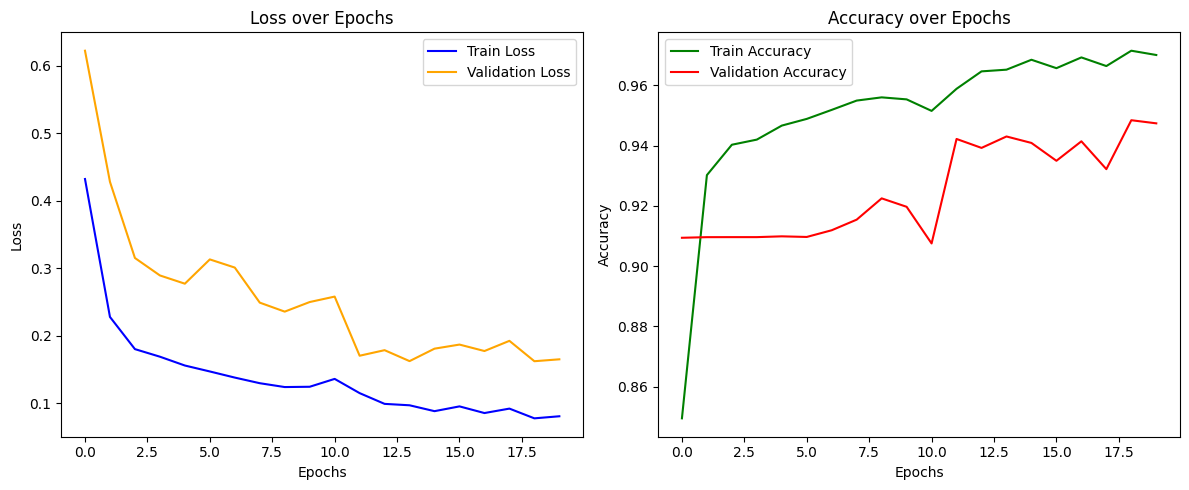

In [55]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='green')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


In [56]:
u_net.save('final_breast_seg_model.keras')

<a id="1"></a>
<div style="text-align: center; background: #1ED760; font-family: 'Trebuchet MS', Arial, sans-serif; color: white; padding: 15px; font-size: 26px; font-weight: bold; line-height: 1; border-radius: 50% 0 50% 0 / 40px; margin-bottom: 20px; box-shadow: 0px 4px 6px rgba(0, 0, 0, 0.1);">5. Test</div>


In [57]:
model = load_model('final_breast_seg_model.keras')

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 228ms/step


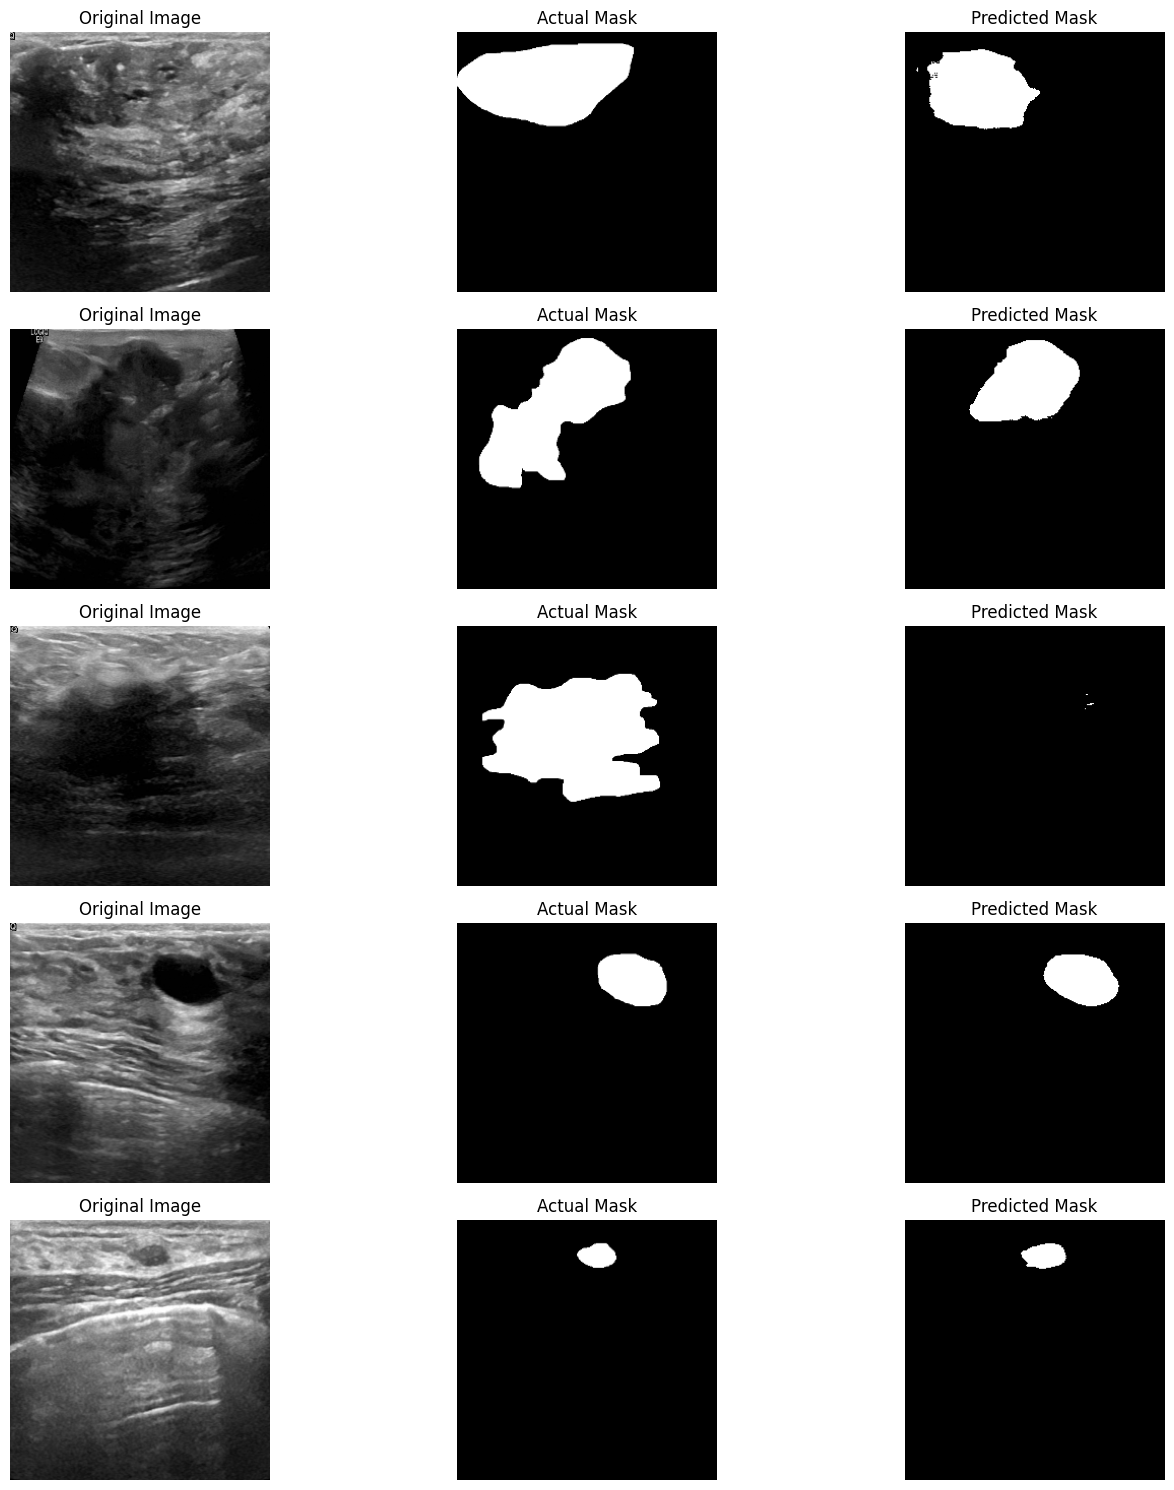

In [59]:
preds = model.predict(X_test)

preds = (preds > 0.5).astype(np.uint8)

n = 5
plt.figure(figsize=(15, n * 3))

for i, _ in enumerate(np.random.randint(0, len(X_test), n)):
    plt.subplot(n, 3, i * 3 + 1)
    plt.imshow(X_test[_].squeeze(), cmap='gray')
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(n, 3, i * 3 + 2)
    plt.imshow(y_test[_].squeeze(), cmap='gray')
    plt.title("Actual Mask")
    plt.axis('off')

    plt.subplot(n, 3, i * 3 + 3)
    plt.imshow(preds[_].squeeze(), cmap='gray')
    plt.title("Predicted Mask")
    plt.axis('off')

plt.tight_layout()
plt.show()
